# LangGraph Agent
## Without tools

## Library Imports

In [12]:
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph, MessagesState
import logging
from IPython.display import Image, Markdown, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles
from langchain_google_genai import ChatGoogleGenerativeAI
import os


## Configure logging

In [13]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(
    filename='langgraph_notebook.log',
    level=logging.INFO,
)

## Configure Agent and Model

In [21]:
import os
from dotenv import load_dotenv

load_dotenv()  # This loads .env into environment variables

# Access the Google API key from the environment variables
google_api_key = os.getenv("GOOGLE_API_KEY")

if google_api_key:
    os.environ["GOOGLE_API_KEY"] = google_api_key  # Set it explicitly if needed (though load_dotenv usually does this)
    model = ChatGoogleGenerativeAI(
        model="gemini-2.0-flash",
        temperature=0,
        google_api_key=google_api_key  # Pass the API key directly to the model
    )
    print(f"Google API Key loaded from .env: {google_api_key[:8]}...") # Print a masked version
else:
    print("Error: GOOGLE_API_KEY not found in .env file.")
    model = None # Or handle the error as appropriate for your application

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)

def call_model(state: MessagesState):
    messages = state['messages']
    response = model.invoke(messages)
    return {"messages": [response]}

workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)

workflow.add_edge(START, "agent")

checkpointer = MemorySaver()

app = workflow.compile(checkpointer=checkpointer)



Google API Key loaded from .env: AIzaSyD5...


## Visualize the Graph

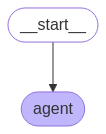

In [22]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## Chat with the Agent

In [23]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What teams did Joe Montana play for?")]},
    config={"configurable": {"thread_id": 99}}
)
display(Markdown(final_state["messages"][-1].content))


Joe Montana played for two teams in his NFL career:

*   **San Francisco 49ers (1979-1992)**
*   **Kansas City Chiefs (1993-1994)**

In [24]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What are the leagues in the SportsWorldCentral fantasy football platform?")]},
    config={"configurable": {"thread_id": 99}}
)
display(Markdown(final_state["messages"][-1].content))

I am sorry, but I do not have access to real-time information about specific fantasy football platforms like "SportsWorldCentral" and their current league offerings. My knowledge is based on the data I was trained on, and I cannot browse the internet or access external databases to provide up-to-date details on such platforms.

To find out the leagues available on SportsWorldCentral, you would need to:

1.  **Visit the SportsWorldCentral website:** Look for a section on fantasy football or league types.
2.  **Check their app (if they have one):** The app might have a league directory or information on available formats.
3.  **Contact their customer support:** They would be the most reliable source for current league information.

In [25]:
final_state = app.invoke(
    {"messages": [HumanMessage(content="What are the leagues in the MyFantasyLeague fantasy football platform?")]},
    config={"configurable": {"thread_id": 99}}
)
display(Markdown(final_state["messages"][-1].content))

MyFantasyLeague (MFL) is known for its highly customizable and flexible platform. Because of this, the "leagues" aren't pre-defined in the same way as on platforms like ESPN or Yahoo. Instead, commissioners have a huge amount of control over the rules and structure of their leagues.

However, here are some *common* league types and variations you'll find on MFL, based on the settings commissioners choose:

*   **Redraft:** The most common type. Teams draft new players each year.
*   **Dynasty:** Owners keep most or all of their players from year to year. This requires long-term strategy and player evaluation.
*   **Keeper:** A hybrid of redraft and dynasty. Owners keep a limited number of players from the previous season.
*   **Auction:** Instead of a traditional draft, owners bid on players.
*   **Salary Cap:** Each team has a salary cap and must stay under it when acquiring players.
*   **IDP (Individual Defensive Players):** Leagues that include individual defensive players in addition to offensive players.
*   **Superflex/2QB:** Leagues that allow you to start a quarterback in a flex position, increasing the value of quarterbacks.
*   **TE Premium:** Leagues that give tight ends extra points per reception or yard, increasing their value.
*   **PPR (Points Per Reception):** Leagues that award points for each reception.
*   **Half PPR:** Leagues that award half a point for each reception.
*   **Best Ball:** You draft a team, and the optimal lineup is automatically selected each week. No in-season management is required.
*   **Empire Leagues:** A league where the pot grows each year until someone wins it twice in a row, then the league resets.
*   **Contract Leagues:** Players are assigned contracts, adding another layer of complexity to team management.

**Key Takeaway:** The beauty of MFL is the *combination* of these settings. You might have a Dynasty league with IDP, Superflex, and TE Premium scoring. The possibilities are vast.

**How to find specific leagues on MFL:**

*   **MFL Forums/Message Boards:** MFL has active forums where people often advertise open spots in their leagues.
*   **Fantasy Football Communities:** Look for leagues advertised on Reddit (r/fantasyfootball), Discord servers, or other fantasy football communities.
*   **Word of Mouth:** The best way to find a good MFL league is often through friends or acquaintances who already play on the platform.

When looking for a league, pay close attention to the league rules, scoring settings, and the commissioner's style of management to ensure it's a good fit for you. Good luck!